  cell_line  motif     ratio  DRACH
0    HCT116  GGACT  0.106509  DRACH
1    HCT116  AGACT  0.034577  DRACH
2    HCT116  GGACC  0.013624  DRACH
3    HCT116  GGACA  0.010603  DRACH
4      A549  GGACT  0.086572  DRACH


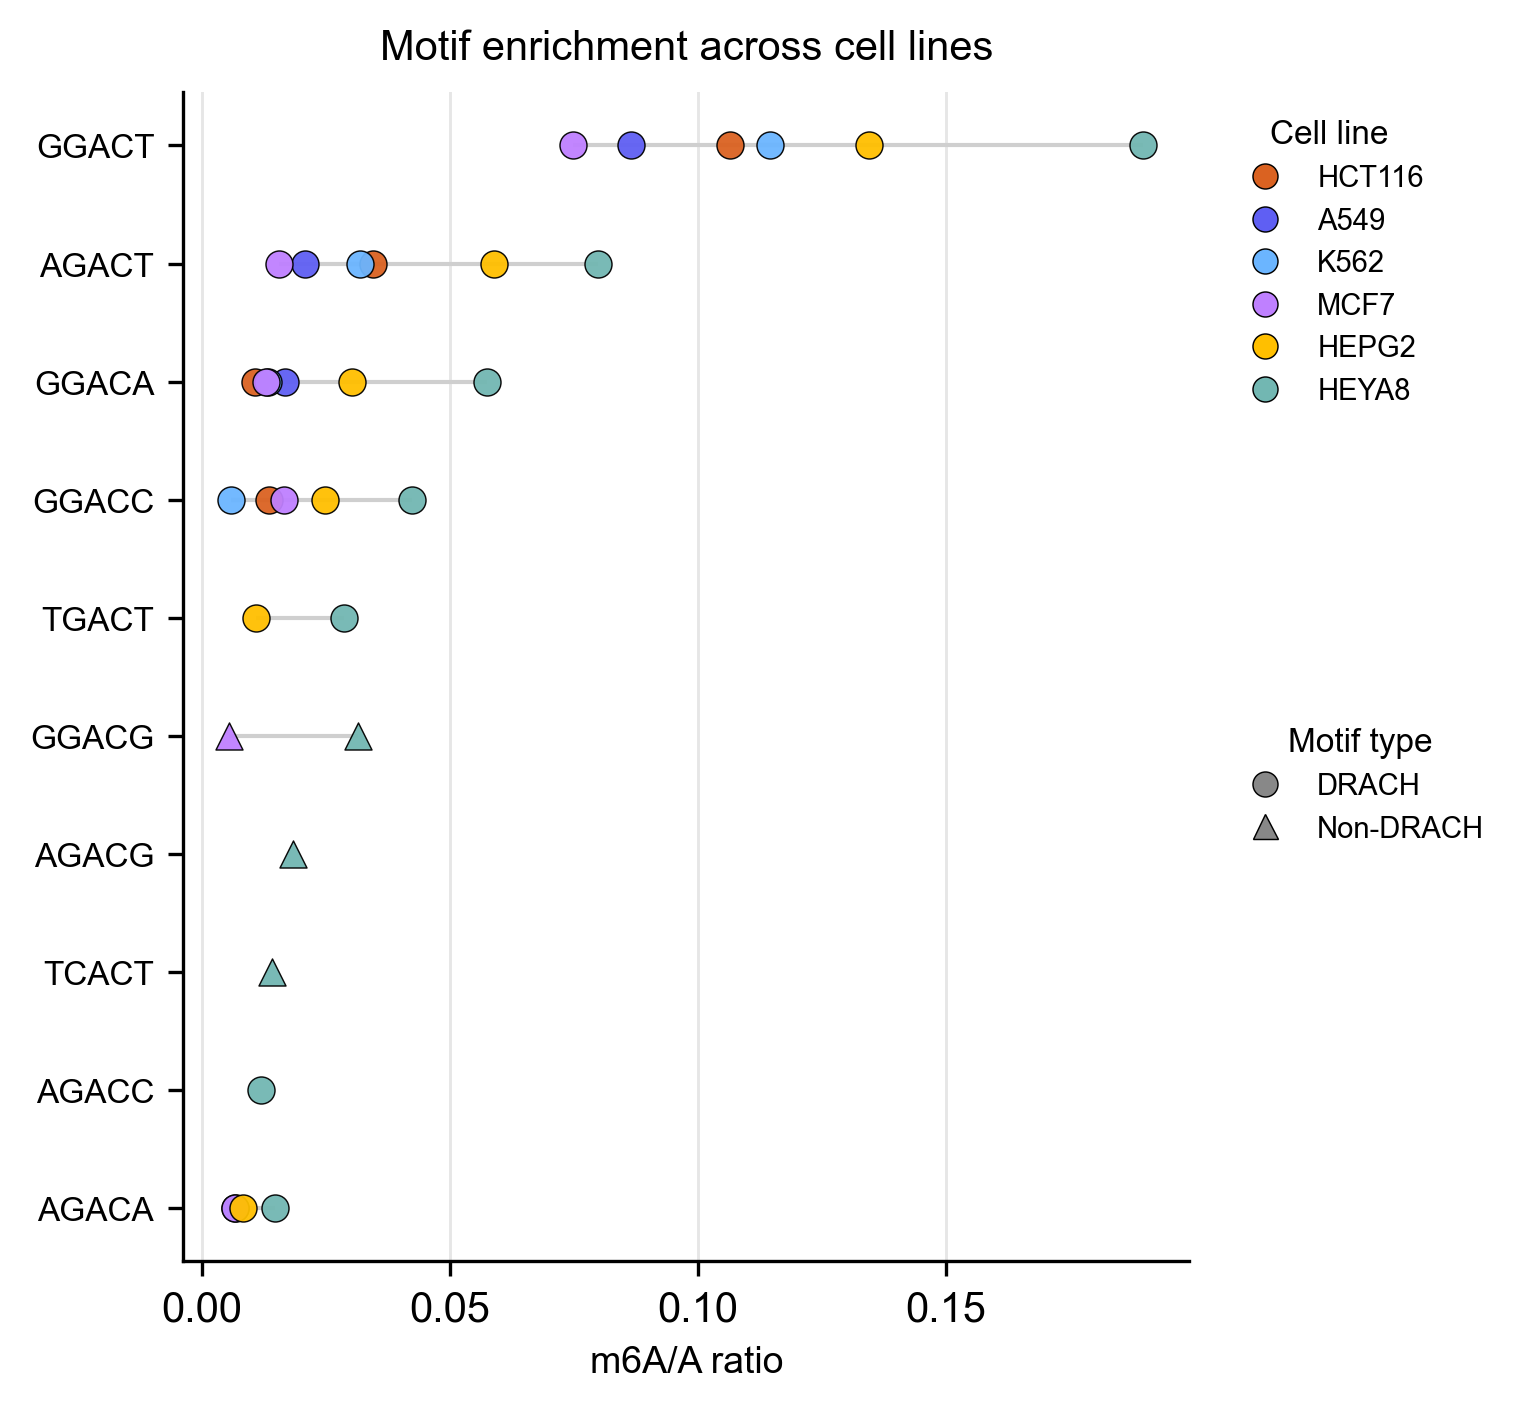

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

# =========================
# =========================
cell_files = {
    "HCT116": "/mnt/sunxh/humancell_dataset/predict.hct116.tsv",
    "A549":   "/mnt/sunxh/humancell_dataset/predict.a549.tsv",
    "K562":   "/mnt/sunxh/humancell_dataset/predict.k562.tsv",
    "MCF7":   "/mnt/sunxh/humancell_dataset/predict.MCF7.tsv",
    "HEPG2":  "/mnt/sunxh/humancell_dataset/predict.HEPG2.tsv",
    "HEYA8":   "/mnt/sunxh/humancell_dataset/predict.HEY8.tsv",
}

# =========================
# =========================
PROB_TH = 0.98
MIN_DEPTH = 5
SITE_POS_FRAC = 0.5
MOTIF_RATIO_TH = 0.010
TOP_N = 10
KMER_FILTER = r"[AGT][AG]AC[ACT]"
cell_params = {
    "HCT116": {"PROB_TH": 0.98, "MIN_DEPTH": 5, "SITE_POS_FRAC": 0.5, "MOTIF_RATIO_TH": 0.010},
    "A549":   {"PROB_TH": 0.98, "MIN_DEPTH": 5, "SITE_POS_FRAC": 0.5, "MOTIF_RATIO_TH": 0.010},
    "K562":   {"PROB_TH": 0.98, "MIN_DEPTH": 5, "SITE_POS_FRAC": 0.5, "MOTIF_RATIO_TH": 0.005},
    "MCF7":   {"PROB_TH": 0.98, "MIN_DEPTH": 5, "SITE_POS_FRAC": 0.5, "MOTIF_RATIO_TH": 0.005},
    "HEPG2":  {"PROB_TH": 0.98, "MIN_DEPTH": 5, "SITE_POS_FRAC": 0.5, "MOTIF_RATIO_TH": 0.005},
    "HEYA8":   {"PROB_TH": 0.90, "MIN_DEPTH": 5, "SITE_POS_FRAC": 0.5, "MOTIF_RATIO_TH": 0.0099},
}
# =========================
# =========================
def extract_top_motifs(tsv_file, cell_name,
                       prob_th=0.98,
                       min_depth=5,
                       site_pos_frac=0.5,
                       motif_ratio_th=0.010,
                       top_n=10,
                       kmer_filter=r"[AGT][AG]AC[ACT]"):

    site_dict = {}

    with open(tsv_file) as f:
        for line in f:
            line = line.rstrip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 6:
                continue

            sid = "|".join(parts[0:3])   # transcript|pos|motif
            try:
                prob = float(parts[5])
            except:
                continue

            if sid not in site_dict:
                site_dict[sid] = [0, 0]   # [high_prob_count, total_count]
            if prob > prob_th:
                site_dict[sid][0] += 1
            site_dict[sid][1] += 1

    motif_dict = {}
    for sid, (mod_n, total_n) in site_dict.items():
        motif = sid.split("|")[2]
        if motif not in motif_dict:
            motif_dict[motif] = [0, 0]   # [positive_sites, total_sites]

        if total_n < min_depth:
            continue

        if mod_n / total_n >= site_pos_frac:
            motif_dict[motif][0] += 1
        motif_dict[motif][1] += 1

    rows = []
    for motif, (pos_sites, total_sites) in motif_dict.items():
        if total_sites == 0:
            continue
        ratio = pos_sites / total_sites
        if ratio <= motif_ratio_th:
            continue

        drach = "DRACH" if re.search(kmer_filter, motif) else "Non-DRACH"
        rows.append({
            "cell_line": cell_name,
            "motif": motif,
            "ratio": ratio,
            "DRACH": drach
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    df = df.sort_values("ratio", ascending=False).head(top_n).copy()
    return df

# =========================
# =========================
all_df = []
for cell, path in cell_files.items():
    if not os.path.exists(path):
        print(f"[WARNING] file not found: {path}")
        continue

    if cell not in cell_params:
        print(f"[WARNING] no parameter set for: {cell}")
        continue

    params = cell_params[cell]

    tmp = extract_top_motifs(
        path,
        cell,
        prob_th=params["PROB_TH"],
        min_depth=params["MIN_DEPTH"],
        site_pos_frac=params["SITE_POS_FRAC"],
        motif_ratio_th=params["MOTIF_RATIO_TH"],
        top_n=TOP_N,
        kmer_filter=KMER_FILTER
    )
    all_df.append(tmp)

data = pd.concat(all_df, ignore_index=True)

data.to_csv("/mnt/sunxh/sunxh/wattmamba/result/motif_long_table_for_dotplot.csv",
            index=False)

print(data.head())

# =========================
# =========================
motif_order = (
    data.groupby("motif")["ratio"]
    .mean()
    .sort_values(ascending=True)
    .index
    .tolist()
)

cell_order = list(cell_files.keys())
cell_order = [x for x in cell_order if x in data["cell_line"].unique()]

cell_colors = {
    "A549":   "#5F5FF3",
    "HCT116": "#DA6221",
    "HEPG2":  "#FFBF00",
    "MCF7":   "#BF80FF",
    "K562":   "#6BB5FF",
    "HEYA8":   "#72B7B2",
}

# =========================
# =========================
plt.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(figsize=(5.2, 4.8), dpi=300)

y_pos = {motif: i for i, motif in enumerate(motif_order)}

for motif in motif_order:
    sub = data[data["motif"] == motif]
    if len(sub) >= 2:
        xmin = sub["ratio"].min()
        xmax = sub["ratio"].max()
        ax.hlines(y=y_pos[motif], xmin=xmin, xmax=xmax,
                  color="#CFCFCF", lw=1.0, zorder=1)

for cell in cell_order:
    sub = data[data["cell_line"] == cell]
    ys = [y_pos[m] for m in sub["motif"]]
    xs = sub["ratio"].values
    markers = ["o" if x == "DRACH" else "^" for x in sub["DRACH"]]

    for x, y, mk in zip(xs, ys, markers):
        ax.scatter(
            x, y,
            s=42,
            color=cell_colors.get(cell, "#666666"),
            marker=mk,
            edgecolor="black",
            linewidth=0.35,
            zorder=3,
            alpha=0.95
        )

ax.set_yticks(range(len(motif_order)))
ax.set_yticklabels(motif_order, fontsize=8)
ax.set_xlabel("m6A/A ratio", fontsize=9)
ax.set_ylabel("")
ax.set_title("Motif enrichment across cell lines", fontsize=10, pad=8)

ax.grid(axis="x", color="#E6E6E6", lw=0.7)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

cell_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cell_colors[c], markeredgecolor='black',
           markeredgewidth=0.35, markersize=6, label=c)
    for c in cell_order
]

shape_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#888888", markeredgecolor='black',
           markeredgewidth=0.35, markersize=6, label="DRACH"),
    Line2D([0], [0], marker='^', color='w',
           markerfacecolor="#888888", markeredgecolor='black',
           markeredgewidth=0.35, markersize=6, label="Non-DRACH")
]

leg1 = ax.legend(handles=cell_handles, title="Cell line",
                 loc="upper left", bbox_to_anchor=(1.02, 1.00),
                 frameon=False, fontsize=7, title_fontsize=8)
ax.add_artist(leg1)

ax.legend(handles=shape_handles, title="Motif type",
          loc="upper left", bbox_to_anchor=(1.02, 0.48),
          frameon=False, fontsize=7, title_fontsize=8)

plt.tight_layout()
out_pdf = "/mnt/sunxh/sunxh/wattmamba/figure/cleveland_dotplot_motif_celllines.pdf"
plt.savefig(out_pdf, bbox_inches="tight",dpi=1200)
plt.show()

In [3]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
motif_order = (
    data.groupby("motif")["ratio"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(figsize=(3.8, 3.5), dpi=2400)
x_pos = {motif: i for i, motif in enumerate(motif_order)}

for motif in motif_order:
    sub = data[data["motif"] == motif]
    if len(sub) >= 2:
        ymin = sub["ratio"].min()
        ymax = sub["ratio"].max()
        ax.vlines(
            x=x_pos[motif],
            ymin=ymin,
            ymax=ymax,
            color="#D6D6D6",
            lw=0.9,
            zorder=1
        )

for cell in cell_order:
    sub = data[data["cell_line"] == cell]
    sub = sub[sub["motif"].isin(x_pos.keys())]

    xs = [x_pos[m] for m in sub["motif"]]
    ys = sub["ratio"].values
    markers = ["o" if x == "DRACH" else "^" for x in sub["DRACH"]]

    for x, y, mk in zip(xs, ys, markers):
        ax.scatter(
            x, y,
            s=34,
            color=cell_colors.get(cell, "#666666"),
            marker=mk,
            edgecolor="black",
            linewidth=0.3,
            zorder=3,
            alpha=0.95
        )

ax.set_xticks(range(len(motif_order)))
ax.set_xticklabels(motif_order, fontsize=7.2, rotation=90)
ax.set_ylabel("m6A/A ratio", fontsize=8.5)
ax.set_xlabel("")
ax.set_title("Motif enrichment across cell lines", fontsize=9.5, pad=6)

ax.set_xlim(-0.35, len(motif_order) - 0.65)

ax.grid(axis="y", color="#E6E6E6", lw=0.6)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(axis='y', labelsize=7.5, width=0.8, length=3)
ax.tick_params(axis='x', width=0.0, length=0, pad=2)

cell_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cell_colors[c], markeredgecolor='black',
           markeredgewidth=0.3, markersize=5.5, label=c)
    for c in cell_order
]

shape_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#888888", markeredgecolor='black',
           markeredgewidth=0.3, markersize=5.5, label="DRACH"),
    Line2D([0], [0], marker='^', color='w',
           markerfacecolor="#888888", markeredgecolor='black',
           markeredgewidth=0.3, markersize=5.5, label="Non-DRACH")
]

leg1 = ax.legend(
    handles=cell_handles,
    title="Cell line",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.00),
    frameon=False,
    fontsize=6.8,
    title_fontsize=7.5,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.4
)
ax.add_artist(leg1)

ax.legend(
    handles=shape_handles,
    title="Motif type",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.55),
    frameon=False,
    fontsize=6.8,
    title_fontsize=7.5,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.4
)

plt.tight_layout(pad=0.4)
out_pdf = "/mnt/sunxh/sunxh/wattmamba/figure/cleveland_dotplot_motif_celllines_top15_rotated90.pdf"
plt.savefig(out_pdf, bbox_inches="tight", dpi=2400)
plt.show()